In [1]:
import pandas as pd
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt


In [2]:
df_train = pd.read_csv('../data/train.csv')
df_val = pd.read_csv('../data/val.csv')
df_test = pd.read_csv('../data/test.csv')

label2id = {'BRCA': 0, 'LUAD': 1, 'PRAD': 2}

df_train['label'] = df_train['cancer_type'].map(label2id)
df_val['label'] = df_val['cancer_type'].map(label2id)
df_test['label'] = df_test['cancer_type'].map(label2id)

print("Train:", len(df_train), "Val:", len(df_val), "Test:", len(df_test))

Train: 1574 Val: 197 Test: 197


In [21]:
class HeadTailDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=512, head=128, tail=382):
        self.texts = df['text'].tolist()
        self.labels = df['label'].tolist()
        self.tokenizer = tokenizer
        self.head = head
        self.tail = tail

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        tokens = self.tokenizer.encode(self.texts[idx], add_special_tokens=False)

        if len(tokens) <= 510:
            selected = tokens[:510]
        else:
            selected = tokens[:self.head] + tokens[-self.tail:]
            
        selected = [self.tokenizer.cls_token_id] + selected + [self.tokenizer.sep_token_id]

        padding_len = 512 - len(selected)
        input_ids = selected + [self.tokenizer.pad_token_id] * padding_len
        attention_mask = [1] * len(selected) + [0] * padding_len

        return {
            'input_ids': torch.tensor(input_ids, dtype=torch.long),
            'attention_mask': torch.tensor(attention_mask, dtype=torch.long),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [22]:
tokenizer = AutoTokenizer.from_pretrained('emilyalsentzer/Bio_ClinicalBERT')

train_dataset = HeadTailDataset(df_train, tokenizer)
val_dataset = HeadTailDataset(df_val, tokenizer)
test_dataset = HeadTailDataset(df_test, tokenizer)

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 1574
Val: 197
Test: 197


In [23]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print("Batches\n Train:", len(train_loader), "Val:", len(val_loader), "Test:", len(test_loader))

Batches
 Train: 99 Val: 13 Test: 13


In [24]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

model = AutoModelForSequenceClassification.from_pretrained(
    'emilyalsentzer/Bio_ClinicalBERT',
    num_labels=3
)
model = model.to(device)

print("Device:", device)
print("Model loaded")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Conside

Device: mps
Model loaded


In [25]:
def train_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0

    for batch in loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


In [26]:
def evaluate(model, loader, device):
    model.eval()
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            probs = torch.softmax(outputs.logits, dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')
    return auc

In [27]:
optimizer = AdamW(model.parameters(), lr=2e-5)

epochs = 3
train_losses = []
val_aucs = []

for epoch in range(epochs):
    train_loss = train_epoch(model, train_loader, optimizer, device)
    val_auc = evaluate(model, val_loader, device)

    train_losses.append(train_loss)
    val_aucs.append(val_auc)

    print(f"Epoch {epoch+1} | Loss: {train_loss:.4f} | Val AUC: {val_auc:.4f}")

Epoch 1 | Loss: 0.4226 | Val AUC: 1.0000
Epoch 2 | Loss: 0.0197 | Val AUC: 1.0000
Epoch 3 | Loss: 0.0140 | Val AUC: 1.0000


In [28]:
test_auc = evaluate(model, test_loader, device)
print(f"Test AUC: {test_auc:.4f}")

Test AUC: 1.0000


In [29]:
model.save_pretrained('../results/clinicalbert_headtail')
tokenizer.save_pretrained('../results/clinicalbert_headtail')
print("Saved")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved


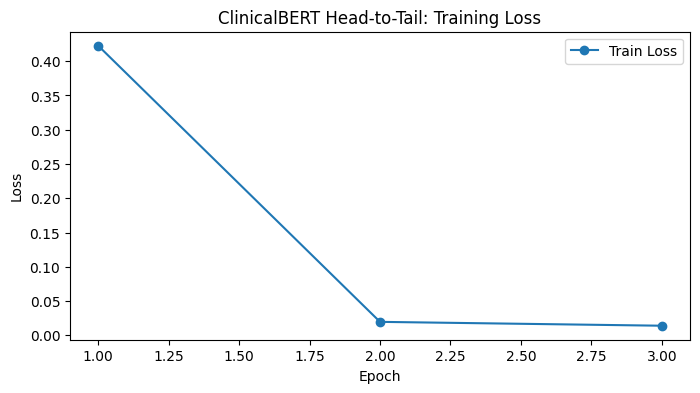

In [30]:
plt.figure(figsize=(8, 4))
plt.plot([1, 2, 3], train_losses, marker='o', label='Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('ClinicalBERT Head-to-Tail: Training Loss')
plt.legend()
plt.savefig('../results/headtail_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()